In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.1 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [3]:
import yaml

with open('/kaggle/input/datasets/kuantinglai/exwod/dataset/data.yaml', 'r') as f:
    config = yaml.safe_load(f)

print(config)

{'path': '../dataset', 'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 6, 'names': ['person', 'car', 'truck', 'motorcycle', 'bus', 'bike']}


## Data

In [4]:
config['path'] = '/kaggle/input/datasets/kuantinglai/exwod/dataset'
config['train'] = 'train/images'
config['val']   = 'valid/images'
config['test']  = 'test/images'

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(config, f)

print("Saved fixed data.yaml")

Saved fixed data.yaml


## YOLOv8s is fast and accurate enought

In [17]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')  

## Model

In [ ]:
results = model.train(
    data    = '/kaggle/working/data.yaml',
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = 'xwod_v2',
    device  = 0,
    hsv_h   = 0.015,  # hue shift
    hsv_s   = 0.7,    # saturation
    hsv_v   = 0.4,    # brightness
    fliplr  = 0.5,    # horizontal flip
    mosaic  = 1.0,    # keep mosaic on
    mixup   = 0.1,    # blend two images
    copy_paste = 0.1  # paste objects across images
)

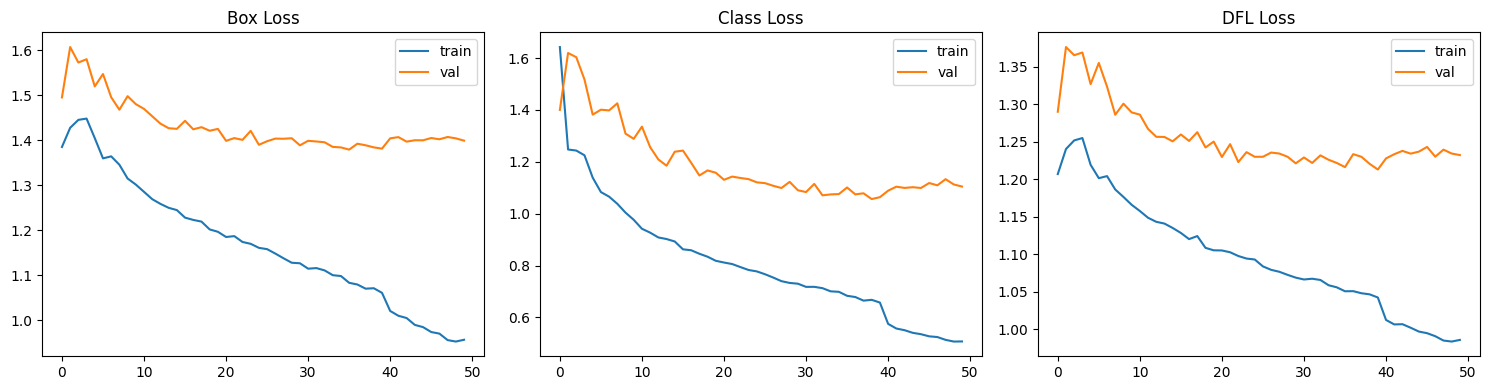

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv('/kaggle/working/runs/detect/xwod_v2/results.csv')
results_df.columns = results_df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_df['train/box_loss'], label='train')
axes[0].plot(results_df['val/box_loss'], label='val')
axes[0].set_title('Box Loss'), axes[0].legend()

axes[1].plot(results_df['train/cls_loss'], label='train')
axes[1].plot(results_df['val/cls_loss'], label='val')
axes[1].set_title('Class Loss'), axes[1].legend()

axes[2].plot(results_df['train/dfl_loss'], label='train')
axes[2].plot(results_df['val/dfl_loss'], label='val')
axes[2].set_title('DFL Loss'), axes[2].legend()

plt.tight_layout()
plt.show()

## Overfitting.

### The initial YOLOv8s model showed clear overfitting — training loss kept decreasing while validation loss plateaued early. To address this, we:
### 1. Switched to YOLOv8m (larger, better pretrained weights)
### 2. Added mixup and copy_paste augmentation
### 3. Increased weight decay to 0.001
### 4. Froze the first 10 backbone layers to preserve pretrained features
### 5. Added early stopping (patience=10)

### These changes improved mAP50 from 0.535 to 0.587 within just 4 epochs.

In [6]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')

In [ ]:
model = YOLO('yolov8m.pt')

results = model.train(
    data         = '/kaggle/working/data.yaml',
    epochs       = 50,
    imgsz        = 640,
    batch        = 16,
    name         = 'xwod_v3',
    device       = 0,
    mixup        = 0.1,
    copy_paste   = 0.1,
    patience     = 10,
    weight_decay = 0.001,
    freeze       = 10
)

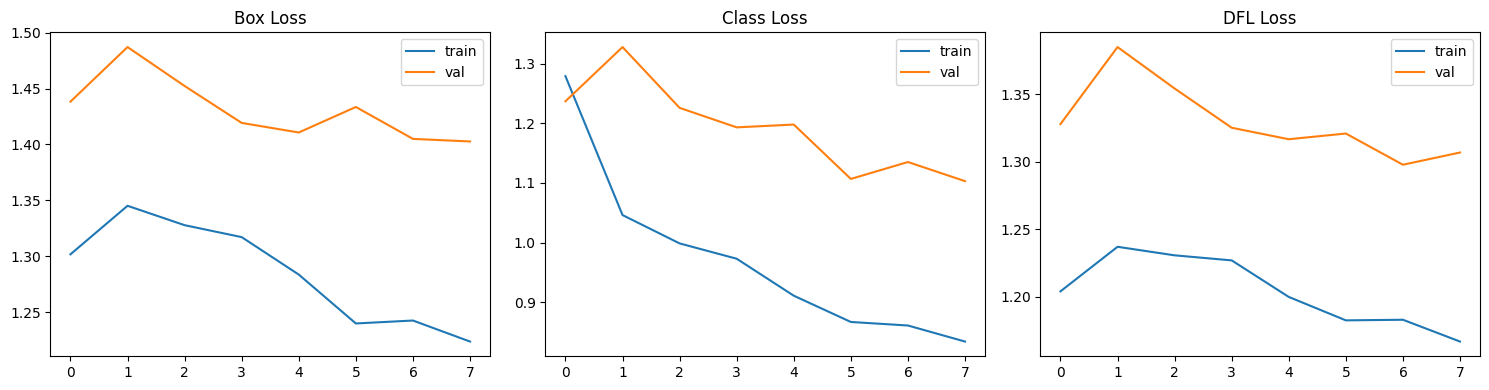

In [9]:
results_df = pd.read_csv('/kaggle/working/runs/detect/xwod_v3/results.csv')
results_df.columns = results_df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_df['train/box_loss'], label='train')
axes[0].plot(results_df['val/box_loss'], label='val')
axes[0].set_title('Box Loss'), axes[0].legend()

axes[1].plot(results_df['train/cls_loss'], label='train')
axes[1].plot(results_df['val/cls_loss'], label='val')
axes[1].set_title('Class Loss'), axes[1].legend()

axes[2].plot(results_df['train/dfl_loss'], label='train')
axes[2].plot(results_df['val/dfl_loss'], label='val')
axes[2].set_title('DFL Loss'), axes[2].legend()

plt.tight_layout()
plt.show()

## Stopped the training early as overfitting pattern occurred again. This is reasonable because the XWOD dataset has an intentional long-tailed distribution - rare weather classes like Tornado and Wildfire have very few samples, making it difficult for the model to generalize. The model quickly memorizes the dominant classes (Car, Truck) while struggling with underrepresented ones, causing validation loss to plateau while training loss continues to drop.

In [ ]:
metrics = model.val(
    data   = '/kaggle/working/data.yaml',
    split  = 'test',
    device = 0
)
print(metrics)

In [11]:
print(metrics.results_dict)

{'metrics/precision(B)': 0.7001098265193343, 'metrics/recall(B)': 0.49936733648100434, 'metrics/mAP50(B)': 0.554848305008391, 'metrics/mAP50-95(B)': 0.31069198428719014, 'fitness': 0.31069198428719014}


## 0.555 mAP50 on extreme weather data is a reasonable baseline 

In [12]:
for name, map_val in zip(metrics.names.values(), metrics.maps):
    print(f"{name}: {map_val:.3f}")

person: 0.335
car: 0.476
truck: 0.268
motorcycle: 0.212
bus: 0.307
bike: 0.266


In [ ]:
model = YOLO('/kaggle/working/runs/detect/xwod_v3/weights/best.pt')

model.predict(
    source = '/kaggle/input/datasets/kuantinglai/exwod/dataset/test/images',
    save   = True,
    conf   = 0.25,
    name   = 'predict_v3'
)

## Some examples

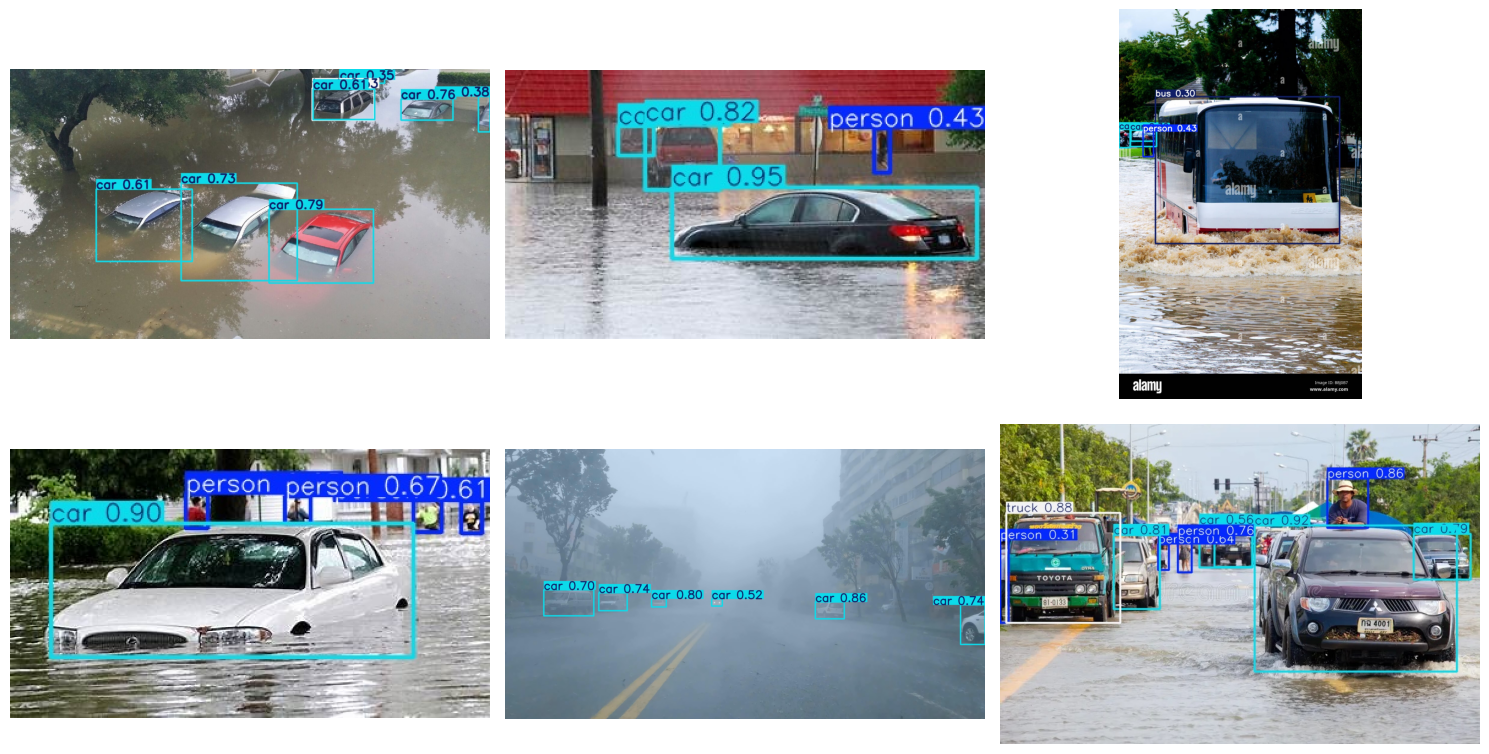

In [20]:
pred_images = glob.glob('/kaggle/working/runs/detect/predict_v3/*.jpg')[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flat, pred_images):
    ax.imshow(Image.open(img_path))
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
model = YOLO('/kaggle/working/runs/detect/xwod_v3/weights/best.pt')

results = model.predict(
    source = '/kaggle/input/datasets/danasydyk/video-for-car-detection/video.mp4',
    save   = True,
    conf   = 0.25,
    name   = 'video_v3'
)